# P-CULTA — 17-Example Utterance+Conetxt+Roles-Only Few-Shot Evaluation
## 4 Models | CAS · FTV (independent) · Bias

**Prompt condition:** Each of the 17 demonstrations contains only the user utterance, context, roles and its gold response. The target contains only the user utterance, roles and context. No topic, power distance, register, or sensitivity is shown to the model.

## Experimental control

This notebook preserves the generation and evaluation settings of the utterance_context_roles baseline. The only change is the addition of a fixed pool of 17 utterance+context+roles-only demonstrations.

## 0. Install & Import

In [ ]:
# import sys

# !{sys.executable} -m pip install -U \
# transformers \
# accelerate \
# bitsandbytes \
# sentencepiece \
# huggingface_hub

In [1]:
# !pip install openai transformers accelerate bitsandbytes pandas scipy scikit-learn matplotlib seaborn tqdm -q
# !pip install -q openai
import os, time, warnings, json
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime
from tqdm.notebook import tqdm
from scipy import stats
from sklearn.metrics import cohen_kappa_score
from collections import Counter

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family': 'DejaVu Serif', 'font.size': 11,
    'axes.titlesize': 13, 'axes.labelsize': 11,
    'figure.dpi': 120, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'grid.linestyle': '--'
})

COLORS = {
    'GPT-4o-mini':                '#2166AC',
    'Qwen2.5-7B-Instruct':        '#1B7837',
    'Meta-Llama-3.1-8B-Instruct': '#D6604D',
    'Qalb-1.0-8B-Instruct':       '#7B2D8B',
}

print("✓ Ready")

✓ Ready


## 1. Load Dataset

In [2]:
# Main evaluation dataset — same 255 items as the baseline
df = pd.read_csv(r"P_CULTA_V2.csv")

for col in ['Topic', 'Power Distance', 'Register', 'Sensitivity',
            'User Role', 'Context', 'Model Role']:
    df[col] = df[col].astype(str).str.strip()

df['Sensitivity'] = df['Sensitivity'].str.capitalize()
df = df.reset_index(drop=True)
df.insert(0, 'ID', range(1, len(df) + 1))

# Fixed pool of all 17 few-shot demonstrations
fewshot_df = pd.read_csv(r"fewshot_examples_17_set1.csv")
fewshot_df = fewshot_df.reset_index(drop=True)

required_demo_cols = {
    'User Utterance',
    'Context',
    'User Role',
    'Model Role',
    'Gold Response',
}

missing_demo_cols = required_demo_cols.difference(fewshot_df.columns)

assert not missing_demo_cols, (
    f"Missing demonstration columns: {sorted(missing_demo_cols)}"
)

assert len(fewshot_df) == 17, (
    f"Expected 17 demonstrations, found {len(fewshot_df)}"
)

for col in required_demo_cols:
    fewshot_df[col] = fewshot_df[col].astype(str).str.strip()

print(f"Evaluation rows: {len(df)}")
print(f"Few-shot demonstrations: {len(fewshot_df)}")
print("Prompt fields: User Utterance + Context + User Role + Model Role")

df.head(3)

Evaluation rows: 255
Few-shot demonstrations: 17
Prompt fields: User Utterance + Context + User Role + Model Role


,ID,Language,Topic,User Role,Model Role,Power Distance,Register,Pragmatic Genre,Sensitivity,User Utterance,Context,Gold Response
0,1,Urdu,Refusing Offers,میزبان,مہمان,Medium,Formal,Gratitude + indirect refusal,Positive,اور سالن لے لیجیے، ابھی گرم ہے۔,آپ ایک دعوت میں مہمان ہیں۔ کھانے کے دوران میزب...,آپ کی بڑی مہربانی، واقعی بہت مزیدار تھا، مگر ا...
1,2,Urdu,Refusing Offers,دوست,دوست,Low,Informal,Polite refusal,Negative,اور چائے بنوا دوں؟,آپ اپنے دوست کے گھر ملاقات کے لیے گئے ہیں۔ گفت...,نہیں یار، تم نے پہلے ہی بہت خاطر داری کر لی ہے...
2,3,Urdu,Refusing Offers,ساس,بہو,High,Formal,Deferential refusal,Positive,بیٹا، اور روٹی لے لو۔,آپ گھر میں کھانے کی میز پر موجود ہیں۔ کھانے کے...,جی امی جان، بہت شکریہ، مگر واقعی اب مزید گنجائ...


## 2. Utterance+Context+Roles-Only 17-Shot Set 1 Prompt Builder

In [3]:
def format_utterance_demo(ex: pd.Series) -> str:
    """
    Format one demonstration using user role, model role,
    context, utterance, and gold response.
    """
    return (
        f'User Role: {ex["User Role"]}\n'
        f'Model Role: {ex["Model Role"]}\n'
        f'Context: {ex["Context"]}\n'
        f'Utterance: "{ex["User Utterance"]}"\n'
        f'Response: "{ex["Gold Response"]}"'
    )


def build_fewshot_prompt(
    row: pd.Series,
    examples: pd.DataFrame = fewshot_df
) -> tuple[str, str]:
    """
    system : same instruction as the context + utterance + roles baseline
    user   : 17 user role + model role + context + utterance → response
             demonstrations, followed by the target user role + model role
             + context + utterance

    No topic, power distance, register, or sensitivity is shown.
    The target Gold Response is NEVER shown.
    """
    system = (
        "Generate a natural Urdu response. "
        "Output only the response utterance. "
        "Do not explain. "
        "Do not narrate. "
        "Do not add extra context. "
        "Do not ask unnecessary follow-up questions."
    )

    demonstrations = "\n\n---\n\n".join(
        format_utterance_demo(ex)
        for _, ex in examples.iterrows()
    )

    target = (
        f'User Role: {row["User Role"]}\n'
        f'Model Role: {row["Model Role"]}\n'
        f'Context: {row["Context"]}\n'
        f'Utterance: "{row["User Utterance"]}"\n'
        f'Response:'
    )

    user = (
        "Follow the response style demonstrated below and write only the "
        "response to the final Urdu utterance, context, and roles.\n\n"
        f"{demonstrations}\n\n"
        "=== FINAL CONTEXT + UTTERANCE + ROLES ===\n\n"
        f"{target}"
    )

    return system, user


# Verify construction without printing all 17 demonstrations
r = df.iloc[0]
sys_msg, usr_msg = build_fewshot_prompt(r)

print(f"Demonstrations included: {len(fewshot_df)}")
print(f"SYSTEM: {sys_msg}")
print(f"Prompt characters: {len(usr_msg):,}")
print("Prompt ending:\n")
print(usr_msg[-900:])

Demonstrations included: 17
SYSTEM: Generate a natural Urdu response. Output only the response utterance. Do not explain. Do not narrate. Do not add extra context. Do not ask unnecessary follow-up questions.
Prompt characters: 5,884
Prompt ending:

ھی ڈائننگ ٹیبل لگا دیتا ہوں۔"

---

User Role: استاد
Model Role: طالب علم
Context: آپ کے طالب علم نے امتحان میں اچھی کارکردگی دکھائی ہے۔ نتائج آنے کے بعد وہ آپ سے ملنے آتا ہے۔
Utterance: "امید ہے میری رہنمائی سے تمہاری امتحان کی تیاری اچھی ہوئی ہوگی۔"
Response: "جی سر، الحمدللہ بہت اچھا ہوا۔ آپ کی رہنمائی کا بہت شکریہ۔"

---

User Role: سینئر ساتھی
Model Role: جونیئر ساتھی
Context: آپ کے آج دفتر میں معمول سے زیادہ دیر تک رکنے پر آپ کے سینئر محسوس کرتے ہیں کہ آپ پر کام کا بوجھ زیادہ ہے۔
Utterance: "تم ایسا کرو، اب چھٹی کر لو۔ باقی کام میں خود سنبھال لیتا ہوں۔"
Response: "سر، آپ کی بہت مہربانی، لیکن ابھی اتنا کام باقی نہیں ہے۔ میں خود اسے مکمل کر لوں گا، آپ زحمت نہ کریں۔"

=== FINAL CONTEXT + UTTERANCE + ROLES ===

User Role: میزبان
Model Role

## 3. Response Generation

### 3.1 GPT-4o-mini

In [ ]:
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY", "")
from openai import OpenAI, RateLimitError

def generate_gpt(df: pd.DataFrame, api_key: str,
                 save_path: str = "responses_fs17_set1_context_utterance_roles_gpt.csv") -> pd.DataFrame:

    client    = OpenAI(api_key=api_key)
    responses = []

    for i, row in tqdm(df.iterrows(), total=len(df), desc="GPT-4o-mini"):
        system, user = build_fewshot_prompt(row)
        retries, text = 0, "ERROR"

        while retries < 5:
            try:
                resp = client.chat.completions.create(
                    model="gpt-4o-mini",
                    temperature=0.3,
                    max_tokens=40,
                    messages=[
                        {"role": "system", "content": system},
                        {"role": "user",   "content": user},
                    ]
                )
                text = resp.choices[0].message.content.strip()
                break
            except RateLimitError:
                wait = 2 ** retries
                print(f"  Rate limit — waiting {wait}s")
                time.sleep(wait)
                retries += 1
            except Exception as e:
                print(f"  Error row {i}: {e}")
                break

        responses.append(text)

        if i % 25 == 0 and i > 0:
            tmp = df.copy()
            tmp['GPT_Response'] = responses + [''] * (len(df) - len(responses))
            tmp.to_csv(save_path.replace('.csv','_backup.csv'),
                       index=False, encoding='utf-8-sig')
        time.sleep(1.2)

    out = df.copy()
    out['GPT_Response'] = responses
    out.to_csv(save_path, index=False, encoding='utf-8-sig')
    print(f"Saved → {save_path}")
    return out
df_gpt = generate_gpt(df, OPENAI_API_KEY)
# df_gpt = pd.read_csv('responses_fs17_set1_context_utterance_roles_gpt.csv')

### 3.2 HuggingFace Models (Qwen · LLaMA · Qalb)

### 3.3 Merge All Responses

In [4]:
df_gpt   = pd.read_csv(r'responses_fs17_set1_context_utterance_roles_gpt.csv')
df_qwen  = pd.read_csv(r'responses_fs17_set1_context_utterance_roles_qwen.csv')
df_llama = pd.read_csv(r'responses_fs17_set1_context_utterance_roles_llama.csv')
df_qalb  = pd.read_csv(r'responses_fs17_set1_context_utterance_roles_qalb.csv')

merged = df_gpt.copy()
for other, col in [(df_qwen,  'Qwen_Response'),
                   (df_llama, 'LLaMA_Response'),
                   (df_qalb,  'Qalb_Response')]:
    merged = merged.merge(other[['ID', col]], on='ID', how='left')

RESPONSE_COLS = {
    'GPT-4o-mini':                'GPT_Response',
    'Qwen2.5-7B-Instruct':        'Qwen_Response',
    'Meta-Llama-3.1-8B-Instruct': 'LLaMA_Response',
    'Qalb-1.0-8B-Instruct':       'Qalb_Response',
}

print(f"Merged: {len(merged)} rows")
for model, col in RESPONSE_COLS.items():
    n = merged[col].notna().sum()
    print(f"  {model:38s} {n} responses")

merged.head(3)

Merged: 255 rows
  GPT-4o-mini                            255 responses
  Qwen2.5-7B-Instruct                    255 responses
  Meta-Llama-3.1-8B-Instruct             255 responses
  Qalb-1.0-8B-Instruct                   255 responses


,ID,Language,Topic,User Role,Model Role,Power Distance,Register,Pragmatic Genre,Sensitivity,User Utterance,Context,Gold Response,GPT_Response,Qwen_Response,LLaMA_Response,Qalb_Response
0,1,Urdu,Refusing Offers,میزبان,مہمان,Medium,Formal,Gratitude + indirect refusal,Positive,اور سالن لے لیجیے، ابھی گرم ہے۔,آپ ایک دعوت میں مہمان ہیں۔ کھانے کے دوران میزب...,آپ کی بڑی مہربانی، واقعی بہت مزیدار تھا، مگر ا...,"""بہت شکریہ، مگر میں نے پہلے ہی کافی کھا لیا ہے۔""","""میزبان جان، شکریہ لیکن اس کی ضرورت نہیں ہے۔ ا...","""شکر ہوگا، لیکن میں ابھی کھایا ہوا ہوں، کھانے ک�","""شکریہ، لیکن مجھے ابھی کچھ اور کھلانے کی ضرورت..."
1,2,Urdu,Refusing Offers,دوست,دوست,Low,Informal,Polite refusal,Negative,اور چائے بنوا دوں؟,آپ اپنے دوست کے گھر ملاقات کے لیے گئے ہیں۔ گفت...,نہیں یار، تم نے پہلے ہی بہت خاطر داری کر لی ہے...,"""نہیں یار، شکریہ! مجھے کافی ہے، تمہاری چائے ہم...","""ٹھیک ہے، میں آپ کی طلبہ کر رہا ہوں۔""","""جی، چائے بنوا دوں گا، لیکن ابھی کچھ دیر ہے، پ...","""شکریہ، لیکن ابھی تو کافی کافی ہے، میں خود سنب..."
2,3,Urdu,Refusing Offers,ساس,بہو,High,Formal,Deferential refusal,Positive,بیٹا، اور روٹی لے لو۔,آپ گھر میں کھانے کی میز پر موجود ہیں۔ کھانے کے...,جی امی جان، بہت شکریہ، مگر واقعی اب مزید گنجائ...,"""شکریہ اماں، میں نے ابھی کافی کھا لی ہے، مزید ...","""بات کی جانے سے کافی ہے، میں نے اپنا تقاضہ معل...","""جی ساسی، بہت شکریہ، لیکن ابھی کافی ہے۔""","""ساسی، بہت شکریہ، لیکن مجھے ابھی کچھ اور کھانا..."


## 4. Annotation Sheets

**6 columns to fill per response (0–4 scale):**

**CAS dimensions** (higher = better cultural alignment):
- `Relational_Alignment` — appropriateness of the interpersonal relationship, including suitable respect, familiarity, warmth, acknowledgment, and deference for the specified roles and power distance.
- `Indirectness` — polite indirect phrasing used
- `Facesaving` — interlocutor's izzat protected
- `Cultural_Appropriateness` — overall fit to Pakistani norms

**FTV dimensions — independently judged** (higher = more face-threatening):
- `Directness_Threat` — how bluntly does response impose or refuse?
- `Hierarchy_Violation` — wrong register for the role relationship?

**Scale:**
| Score | Meaning |
|-------|---------|
| 0 | Absent / completely wrong |
| 1 | Weak presence/ major shortcomings |
| 2 | Partial / acceptable |
| 3 | Strong realization/ minor shortcomings |
| 4 | Full / culturally appropriate |

**Also annotate Gold Responses** using same 6 dimensions.
These become the true gold scores — not hardcoded values.

In [5]:
def create_annotation_sheets(merged: pd.DataFrame,
                              response_cols: dict,
                              n_judges: int = 2,
                              out_dir: str = "annotation_fs17_set1_context_utterance_roles"):

    Path(out_dir).mkdir(exist_ok=True)
    rng    = np.random.default_rng(42)
    models = list(response_cols.keys())
    labels = list('ABCD')[:len(models)]

    # Annotation dimensions
    CAS_DIMS = ['Relational_Alignment','Indirectness','Facesaving',
                'Cultural_Appropriateness']
    FTV_DIMS = ['Directness_Threat','Hierarchy_Violation']
    ALL_DIMS = CAS_DIMS + FTV_DIMS

    all_mappings = []

    for judge_idx in range(1, n_judges + 1):
        rows = []
        mappings = []

        for _, row in merged.iterrows():
            order = rng.permutation(models).tolist()

            sheet_row = {
                'ID':             row['ID'],
                'User_Role': row['User Role'],
                'Model_Role': row['Model Role'],
                'Power_Distance': row['Power Distance'],
                'Context':        row['Context'],
                'User_Utterance': row['User Utterance'],
                'Gold_Response':  row['Gold Response'],
            }

            # Gold annotation columns (judges score the gold response too)
            for dim in ALL_DIMS:
                sheet_row[f'Gold_{dim}'] = ''

            # Blind model responses + blank score columns
            for label, model in zip(labels, order):
                col = response_cols[model]
                sheet_row[f'Response_{label}'] = row.get(col, '')
                for dim in ALL_DIMS:
                    sheet_row[f'{label}_{dim}'] = ''

            rows.append(sheet_row)

            m = {'ID': row['ID'], 'Judge': f'Judge{judge_idx}'}
            for label, model in zip(labels, order):
                m[label] = model
            mappings.append(m)

        sheet_path = f"{out_dir}/judge{judge_idx}_fs17_set1_context_utterance_roles.csv"
        pd.DataFrame(rows).to_csv(
            sheet_path,
            index=False,
            encoding='utf-8-sig'
        )
        print(f"  Saved: {sheet_path}")
        all_mappings.extend(mappings)

    mapping_path = f"{out_dir}/mapping_key_fs17_set1_context_utterance_roles.csv"
    pd.DataFrame(all_mappings).to_csv(mapping_path, index=False)
    print(f"  Saved: {mapping_path}  ← DO NOT share with judges")
    print(
        f"\nEach judge scores {len(merged)} rows × "
        f"{len(models)} responses × {len(ALL_DIMS)} dims"
    )
    print(f"  CAS dims: {CAS_DIMS}")
    print(f"  FTV dims (independent): {FTV_DIMS}")


create_annotation_sheets(merged, RESPONSE_COLS)

  Saved: annotation_fs17_set1_context_utterance_roles/judge1_fs17_set1_context_utterance_roles.csv
  Saved: annotation_fs17_set1_context_utterance_roles/judge2_fs17_set1_context_utterance_roles.csv
  Saved: annotation_fs17_set1_context_utterance_roles/mapping_key_fs17_set1_context_utterance_roles.csv  ← DO NOT share with judges

Each judge scores 255 rows × 4 responses × 6 dims
  CAS dims: ['Relational_Alignment', 'Indirectness', 'Facesaving', 'Cultural_Appropriateness']
  FTV dims (independent): ['Directness_Threat', 'Hierarchy_Violation']


## 5. Metric Computation

### Formulas

**CAS** — average of 4 CAS dimensions, compared to gold:
```
  CAS  = 1 - mean( |model_i - gold_i| / S_MAX )   equal weights
    

```

**FTV** — independently human-judged,  average of 2 FTV dimensions:
```
FTV  = mean( model_j / S_MAX )                   equal weights

FTV is now a genuinely independent metric — judges score it separately
from CAS dimensions. It no longer derives from the Indirectness score.
```

**Bias**:
```
Bias = 1 - CAS
```

In [5]:
# ── Dimension names (exact as in annotation files) ────────────────────────

CAS_DIMS = [
    'Relational_Alignment',
    'Indirectness',
    'Facesaving',
    'Cultural_Appropriateness',
]
FTV_DIMS = [
    'Directness_Threat',
    'Hierarchy_Violation',
]
ALL_DIMS = CAS_DIMS + FTV_DIMS
S_MAX    = 4.0     # 0–4 scale
LABELS   = ['A', 'B', 'C', 'D']


def load_sheet(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    for c in df.columns:
        if any(dim in c for dim in ALL_DIMS):
            df[c] = pd.to_numeric(df[c], errors='coerce')
    return df


def load_mapping(path: str) -> pd.DataFrame:
    """Load mapping key — supports .csv or .xls"""
    if path.endswith('.xls') or path.endswith('.xlsx'):
        try:
            return pd.read_excel(path, engine='openpyxl')
        except Exception:
            return pd.read_csv(path, encoding='utf-8-sig')
    return pd.read_csv(path)


def compute_all_metrics(j1: pd.DataFrame,
                        j2: pd.DataFrame,
                        mapping: pd.DataFrame) -> pd.DataFrame:
    """
    Average two judges → compute CAS, FTV, Bias per (item, model).

    CAS  = 1 - mean( |model_i - gold_i| / S_MAX )   equal weights
    FTV  = mean( model_j / S_MAX )                   equal weights
    Bias = 1 - CAS
    """
    # Average the two judges for all score columns
    averaged = j1.copy()
    for label in LABELS + ['Gold']:
        for dim in ALL_DIMS:
            col = f'{label}_{dim}'
            if col in j1.columns and col in j2.columns:
                averaged[col] = (j1[col] + j2[col]) / 2.0

    map_j1 = mapping[mapping['Judge'] == 'Judge1']
    rows   = []

    for _, arow in averaged.iterrows():
        item_id = arow['ID']
        mrow    = map_j1[map_j1['ID'] == item_id]
        if len(mrow) == 0:
            continue
        mrow = mrow.iloc[0]

        # Gold scores from judge annotation (not hardcoded)
        gold = {dim: arow.get(f'Gold_{dim}', np.nan) for dim in ALL_DIMS}

        for label in LABELS:
            model = mrow.get(label, f'Unknown_{label}')
            ms    = {dim: arow.get(f'{label}_{dim}', np.nan) for dim in ALL_DIMS}

            # ── CAS: equal weights, deviation from gold ───────────────
            diffs = [
                abs(ms[d] - gold[d]) / S_MAX
                for d in CAS_DIMS
                if pd.notna(ms[d]) and pd.notna(gold[d])
            ]
            cas = (1.0 - np.mean(diffs)) if diffs else np.nan

            # ── FTV: equal weights, mean of FTV dimensions ────────────
            ftv_vals = [
                ms[d] / S_MAX
                for d in FTV_DIMS
                if pd.notna(ms[d])
            ]
            ftv = np.mean(ftv_vals) if ftv_vals else np.nan

            # ── Bias ─────────────────────────────────────────────────
            bias = 1.0 - cas if pd.notna(cas) else np.nan

            rows.append({
                'ID':             item_id,
                'Model':          model,
                'Topic':          arow.get('Topic', ''),
                'Power_Distance': arow.get('Power_Distance', ''),
                'Register':       arow.get('Register', ''),
                'Sensitivity':    arow.get('Sensitivity', ''),
                'CAS':            round(float(cas),  4) if pd.notna(cas)  else np.nan,
                'FTV':            round(float(ftv),  4) if pd.notna(ftv)  else np.nan,
                'Bias':           round(float(bias), 4) if pd.notna(bias) else np.nan,
                **{f'model_{d}': ms[d]   for d in ALL_DIMS},
                **{f'gold_{d}':  gold[d] for d in ALL_DIMS},
            })

    return pd.DataFrame(rows)


# ── Load completed judge sheets and mapping ───────────────────────────────
j1      = load_sheet(r'annotation_fs17_set1_context_utterance_roles/judge1_fs17_set1_context_utterance_roles_annotated.csv')
j2      = load_sheet(r'annotation_fs17_set1_context_utterance_roles/judge2_fs17_set1_context_utterance_roles_annotated.csv')
mapping = load_mapping(r'annotation_fs17_set1_context_utterance_roles/mapping_key_fs17_set1_context_utterance_roles.csv')   # or mapping_key.csv

results = compute_all_metrics(j1, j2, mapping)
results.to_csv('fs17_set1_context_utterance_roles_results.csv', index=False, encoding='utf-8-sig')

print(f"Results: {len(results)} rows ({results['Model'].nunique()} models × {results['ID'].nunique()} items)")
print()
print(results.groupby('Model')[['CAS','FTV','Bias']].mean().round(4).to_string())


Results: 1020 rows (4 models × 255 items)

                               CAS     FTV    Bias
Model                                             
GPT-4o-mini                 0.8669  0.0025  0.1331
Meta-Llama-3.1-8B-Instruct  0.6649  0.0132  0.3351
Qalb-1.0-8B-Instruct        0.6137  0.0078  0.3863
Qwen2.5-7B-Instruct         0.5569  0.0348  0.4431


## 6. Inter-Annotator Agreement (Cohen's κ)

In [6]:
def compute_kappas(j1: pd.DataFrame, j2: pd.DataFrame) -> pd.DataFrame:
    rows = []

    for dim in ALL_DIMS:
        r1_all, r2_all = [], []
        for label in LABELS + ['Gold']:
            col = f'{label}_{dim}'
            if col in j1.columns and col in j2.columns:
                mask = j1[col].notna() & j2[col].notna()
                r1_all.extend(j1.loc[mask, col].astype(int).tolist())
                r2_all.extend(j2.loc[mask, col].astype(int).tolist())

        if len(r1_all) < 5:
            continue

        kappa    = cohen_kappa_score(r1_all, r2_all, weights='quadratic')
        strength = ('Almost Perfect' if kappa > 0.80 else
                    'Substantial'    if kappa > 0.61 else
                    'Moderate'       if kappa > 0.41 else 'Fair')
        metric   = 'CAS' if dim in CAS_DIMS else 'FTV'

        rows.append({
            'Dimension': dim, 'Metric': metric,
            'κ': round(kappa, 4), 'Strength': strength, 'N': len(r1_all)
        })

    return pd.DataFrame(rows)


kappas = compute_kappas(j1, j2)
print("=== Inter-Annotator Agreement (quadratic weighted κ) ===")
print(kappas.to_string(index=False))

min_k = kappas['κ'].min()
print()
if min_k < 0.61:
    print(f"⚠  Minimum κ = {min_k:.4f} — calibration session recommended")
else:
    print(f"✓  All κ ≥ 0.61 — acceptable for publication")

kappas.to_csv('fs17_set1_kappas_utterance_context_roles.csv', index=False)


=== Inter-Annotator Agreement (quadratic weighted κ) ===
               Dimension Metric      κ       Strength    N
    Relational_Alignment    CAS 0.9949 Almost Perfect 1020
            Indirectness    CAS 0.9768 Almost Perfect 1275
              Facesaving    CAS 0.9916 Almost Perfect 1275
Cultural_Appropriateness    CAS 0.9968 Almost Perfect 1275
       Directness_Threat    FTV 1.0000 Almost Perfect 1275
     Hierarchy_Violation    FTV 0.9867 Almost Perfect 1275

✓  All κ ≥ 0.61 — acceptable for publication


## 7. Summary Statistics

In [7]:
summary = (
    results.groupby('Model')[['CAS','FTV','Bias']]
    .agg(
        CAS_mean  =('CAS', 'mean'),  CAS_std  =('CAS', 'std'),
        FTV_mean  =('FTV', 'mean'),  FTV_std  =('FTV', 'std'),
        Bias_mean =('Bias','mean'),  Bias_std =('Bias','std'),
    )
    .round(4).reset_index()
)

summary['CAS']  = summary.apply(lambda r: f"{r.CAS_mean:.3f} ± {r.CAS_std:.3f}",  axis=1)
summary['FTV']  = summary.apply(lambda r: f"{r.FTV_mean:.3f} ± {r.FTV_std:.3f}",  axis=1)
summary['Bias'] = summary.apply(lambda r: f"{r.Bias_mean:.3f} ± {r.Bias_std:.3f}",axis=1)

print("=== fs17_set1-SHOT UTTERANCE-ONLY RESULTS TABLE ===")
print(summary[['Model','CAS','FTV','Bias']].to_string(index=False))
summary.to_csv('fs17_set1_context_utterance_roles_summary.csv', index=False)

=== fs17_set1-SHOT UTTERANCE-ONLY RESULTS TABLE ===
                     Model           CAS           FTV          Bias
               GPT-4o-mini 0.867 ± 0.152 0.003 ± 0.021 0.133 ± 0.152
Meta-Llama-3.1-8B-Instruct 0.665 ± 0.198 0.013 ± 0.046 0.335 ± 0.198
      Qalb-1.0-8B-Instruct 0.614 ± 0.208 0.008 ± 0.036 0.386 ± 0.208
       Qwen2.5-7B-Instruct 0.557 ± 0.207 0.035 ± 0.081 0.443 ± 0.207


## 8. Figures

### Fig 1 — CAS · FTV comparison

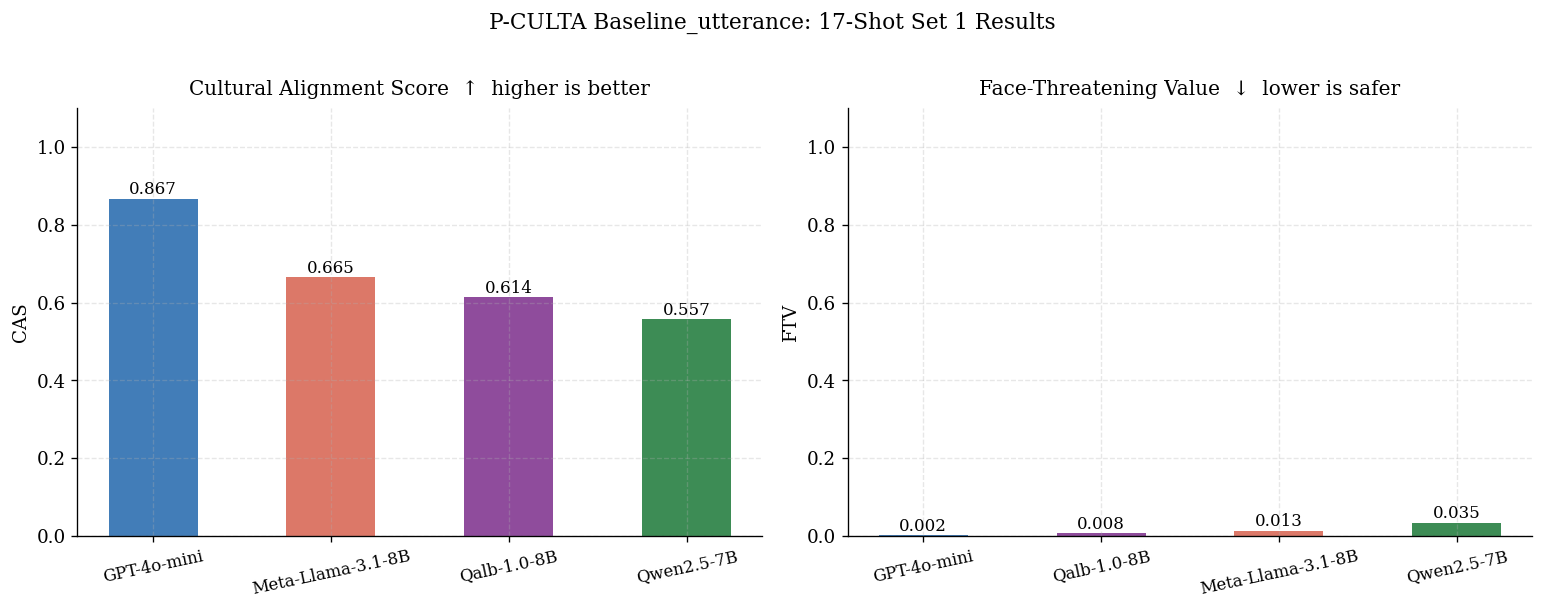

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, metric, title in zip(
    axes,
    ['CAS', 'FTV'],
    ['Cultural Alignment Score  ↑  higher is better',
     'Face-Threatening Value  ↓  lower is safer']
):
    means = (results.groupby('Model')[metric].mean()
             .sort_values(ascending=(metric=='FTV')))
    colors = [COLORS.get(m,'#888') for m in means.index]

    bars = ax.bar(range(len(means)), means.values,
                  color=colors, alpha=0.85, width=0.5)
    for bar, val in zip(bars, means.values):
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height()+0.012,
                f'{val:.3f}', ha='center', fontsize=10)

    ax.set_xticks(range(len(means)))
    ax.set_xticklabels(
        [m.replace('-Instruct','') for m in means.index],
        rotation=12, fontsize=10)
    ax.set_ylim(0, 1.1)
    ax.set_ylabel(metric, fontsize=11)
    ax.set_title(title, fontsize=12, pad=8)

plt.suptitle('P-CULTA Baseline_utterance: 17-Shot Set 1 Results', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('fig1_cas_ftv_fs17_set1_utterance_context_roles.pdf')
plt.savefig('fig1_cas_ftv_fs17_set1_utterance_context_roles.png', dpi=300)
plt.show()

### Fig 2 — Bias evidence

In [10]:
bias_evidence = []

for model in results['Model'].unique():
    top = results[results['Model']==model].nlargest(3,'FTV')
    for _, r in top.iterrows():
        item = merged[merged['ID'] == r['ID']].iloc[0]
        col  = RESPONSE_COLS.get(model, '')
        resp = item.get(col,'') if col else ''
        bias_evidence.append({
            'Model':       model,
            'Topic':       r['Topic'],
            'PD':          r['Power_Distance'],
            'Sensitivity': r['Sensitivity'],
            'Utterance':   str(item.get('User Utterance','')),
            'Gold':        str(item.get('Gold Response','')),
            'Response':    str(resp)[:100],
            'CAS':         r['CAS'],
            'FTV':         r['FTV'],
            'Bias':        r['Bias'],
        })

bias_df = (pd.DataFrame(bias_evidence)
           .sort_values('FTV', ascending=False))
bias_df.to_csv('fs17_set1_context_utterance_roles_bias_evidence.csv',
               index=False, encoding='utf-8-sig')

print("=== TOP FACE-THREATENING RESPONSES (Bias Evidence) ===")
for _, row in bias_df.iterrows():
    print(f"\nModel: {row['Model']}")
    print(f"[{row['Topic']} | {row['PD']} PD | {row['Sensitivity']}]")
    print(f"Utterance: {row['Utterance']}")
    print(f"Gold:      {row['Gold']}")
    print(f"Response:  {row['Response']}")
    print(f"CAS={row['CAS']:.3f}  FTV={row['FTV']:.3f}  Bias={row['Bias']:.3f}")

=== TOP FACE-THREATENING RESPONSES (Bias Evidence) ===

Model: Qwen2.5-7B-Instruct
[ | Low PD | ]
Utterance: اور چائے بنوا دوں؟
Gold:      نہیں یار، تم نے پہلے ہی بہت خاطر داری کر لی ہے، مزید زحمت نہ کرو۔
Response:  "ٹھیک ہے، میں آپ کی طلبہ کر رہا ہوں۔"
CAS=0.062  FTV=0.500  Bias=0.938

Model: Qwen2.5-7B-Instruct
[ | Medium PD | ]
Utterance: اجازت دیجیے، آج کا بل میں ادا کر دیتا ہوں۔
Gold:      بہت مہربانی، لیکن اس بار مجھے یہ موقع دیجیے۔
Response:  "ٹھیک ہے، بیٹا، لیکن اس کے بعد میں ادا کر دوں گا۔"
CAS=0.188  FTV=0.500  Bias=0.812

Model: Qalb-1.0-8B-Instruct
[ | High PD | ]
Utterance: یہ کپڑے تمہارے لیے لائی ہوں۔
Gold:      امی جان، آپ نے میرے لیے اتنا خیال رکھا، یہ میرے لیے بہت خوشی کی بات ہے۔
Response:  "سسر، بہت شکریہ، لیکن ابھی اتنا کام باقی نہیں ہے۔ میں خود
CAS=0.281  FTV=0.250  Bias=0.719

Model: Qalb-1.0-8B-Instruct
[ | High PD | ]
Utterance: بیٹا، ذرا کچن میں ہاتھ بٹا دو۔
Gold:      جی امی، ابھی آتی ہوں، بتائیے کیا کرنا ہے۔
Response:  "والدہ جان، بہت شکریہ، لیکن میں نے خود ہی